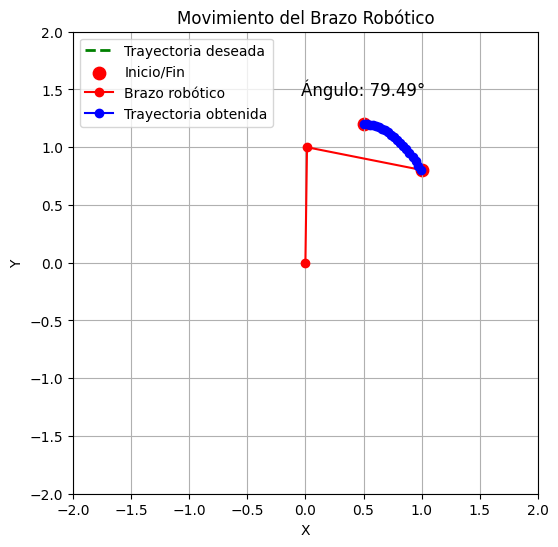

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.optimize import minimize
from IPython.display import HTML

# Parámetros del brazo robótico
L1, L2 = 1.0, 1.0  

# Trayectoria deseada
T = 20  
t_vals = np.linspace(0, 1, T)
x_deseado = 0.5 + 0.5 * t_vals
y_deseado = 1.2 - 0.4 * t_vals**2

# Cinemática Directa
def forward_kinematics(theta1, theta2):
    """ Calcula las coordenadas del codo y la punta del brazo """
    x1 = L1 * np.cos(theta1)
    y1 = L1 * np.sin(theta1)
    x2 = x1 + L2 * np.cos(theta1 + theta2)
    y2 = y1 + L2 * np.sin(theta1 + theta2)
    return (x1, y1), (x2, y2)
#Funcion que calcula la posicion de los puntos utilizando razones trigonometricas conjunto a variables fijas (L1 L2) que indican la longitud
#que hay entre cada punto, x1 y1 correspondiente a el codo, y x2 y2 el extremo.
#Los angulos, theta1 correspondiente al angulo que forma L1 con el eje x, theta2 es el angulo que forman entre si L1 L2 ( angulo del codo)
#Para el calculo de x2 y2 se necesita de una suma de angulos ya que rota respecto al primer segmento, ademas
#como es el segundo segmento y sus coordenadas, tambien se necesita de una suma de longitudes en coordenadas porque el segundo segmento
#se agrega a partir del primer segmento

# Función objetivo para la optimización
def objective_function(thetas):
    theta1_seq, theta2_seq = thetas[:T], thetas[T:]
    _, punta_fk = zip(*[forward_kinematics(theta1_seq[i], theta2_seq[i]) for i in range(T)])
    x_fk, y_fk = np.array(punta_fk).T
    error_trayectoria = np.sum((x_fk - x_deseado)**2 + (y_fk - y_deseado)**2)
    suavidad = np.sum(np.diff(theta1_seq)**2 + np.diff(theta2_seq)**2)
    aceleracion = np.sum(np.diff(theta1_seq, n=2)**2 + np.diff(theta2_seq, n=2)**2)
    return error_trayectoria + 0.3 * suavidad + 0.1 * aceleracion

#Primero hay que establecer dos secuencias de angulos respecto al tiempo (una para theta1 y otra para theta2)
#T/2 para theta1 y de T/2 hasta T para theta2
#Implementamos la funcion de calculo de las coordenadas y hacemos un sistema de ecuaciones (con zip creando dos listas) para cada coordenada en funcion de secuencia del tiempo T
#Con la suma de los cuadrados de la distancia que hay entre coordenada final y la deseada, minimizamos la distancia.
#Usamos el metodo del error cuadratico a fin evitar valores negativos y grandes erroresç
#Creamos el parametro suavidad que va a utilizar el metodo de newton mas la suma de cuadrados para tener una
#secuencia de angulos nitida.
#Calculamos la aceleracion angular para theta1 y theta2, penalizado cambios significativos con la suma de los cuadrados
#el valor final queda definido por la suma del error cometido mas parametro de suavidad y la aceleracion angular

# Optimización
theta_initial = np.random.uniform(-np.pi, np.pi, 2*T)
bounds = [(-np.pi, np.pi)] * (2*T)
theta_opt_result = minimize(objective_function, theta_initial, bounds=bounds, method='SLSQP')

theta1_opt, theta2_opt = theta_opt_result.x[:T], theta_opt_result.x[T:]
#opimizacion usando secuencia de minimos cuadrados
# Crear la figura y el eje
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Movimiento del Brazo Robótico")
ax.grid(True)

# Dibujar la trayectoria deseada
ax.plot(x_deseado, y_deseado, 'g--', label="Trayectoria deseada", linewidth=2)

# Puntos de inicio y fin
ax.scatter([x_deseado[0], x_deseado[-1]], [y_deseado[0], y_deseado[-1]], 
           color='red', marker='o', s=80, label="Inicio/Fin")

# Líneas y puntos del brazo
brazo, = ax.plot([], [], 'ro-', markersize=6, label="Brazo robótico")
trayectoria_obtenida, = ax.plot([], [], 'bo-', label="Trayectoria obtenida")

# Texto para mostrar el ángulo
angulo_texto = ax.text(0.5, 1.5, "", fontsize=12, ha='center', va='center', color='black')

# Función de actualización para la animación
def actualizar(i):
    codo, punta = forward_kinematics(theta1_opt[i], theta2_opt[i])
    
    brazo.set_data([0, codo[0], punta[0]], [0, codo[1], punta[1]])
    
    puntas_optimizadas = np.array([forward_kinematics(theta1_opt[j], theta2_opt[j])[1] for j in range(i+1)])
    trayectoria_obtenida.set_data(puntas_optimizadas[:, 0], puntas_optimizadas[:, 1])
    
    # Calcular el ángulo interno entre los segmentos
    angulo = abs(theta2_opt[i])  # Tomamos el valor absoluto de theta2
    angulo_grados = 180 - np.degrees(angulo)  # Restamos de 180 para obtener el ángulo interno
    
    # Actualizar el texto con el valor del ángulo
    angulo_texto.set_text(f"Ángulo: {angulo_grados:.2f}°")
    
    return brazo, trayectoria_obtenida, angulo_texto

# Crear la animación
ani = animation.FuncAnimation(fig, actualizar, frames=T, interval=200, blit=True)
plt.legend()

# Mostrar animación en Jupyter Notebook
HTML(ani.to_jshtml())